In [2]:
from classy import Class

import os
import copy
import yaml
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

from matplotlib import rc
from scipy.interpolate import interp1d

rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
#matplotlib.rc('font', **font)
matplotlib.rcParams['legend.fontsize']='medium'
plt.rcParams["figure.figsize"] = [8.0,6.0]

# warmup

run a fiducial cosmology

In [3]:
# params_EDE = {
#     # output options
#     #"root": "output/best_fit_paper_Smithetal_",
#     #"write background": "yes",
#     #"write parameters": "yeap",
#     # general computations
#     # "compute_sigma8": "yes",
#     'output':'tCl,pCl,lCl',
#     # 'lensing':'yes',
#     'l_max_scalars':3000,
#     # LCDM parameters
#     "omega_b": 0.02251,
#     "omega_cdm": 0.1320,
#     "H0": 72.81,
#     "tau_reio": 0.068,
#     "A_s": 2.191e-9,
#     "n_s": 0.9860,

#     # neutrinos
#     "N_ur": 2.0328,
#     "N_ncdm": 1,
#     "deg_ncdm": 1,
#     "m_ncdm": 0.06,
#     "T_ncdm": 0.71611,

#     # EDE parameters
#     "N_mscf": 0,
#     "scf_potential": "axion",
#     "n_axion": 2.6,
#     "f_axion": 0.1,
#     "m_axion": 1e4,
#     "scf_parameters": '2.72,0',

#     # extra EDE parameters
#     "scf_evolve_as_fluid": "no",
#     "scf_evolve_like_axionCAMB": "no",
#     "do_shooting": "no",
#     "do_shooting_scf": "no",
#     "attractor_ic_scf": "no",

#     # verbosity
#     "input_verbose": 1,
#     "background_verbose": 1,
#     "thermodynamics_verbose": 1,
#     "perturbations_verbose": 1,
#     "transfer_verbose": 1,
#     "primordial_verbose": 1,
#     #"spectra_verbose": 1,
#     # "nonlinear_verbose": 1,
#     "lensing_verbose": 1,
#     "output_verbose": 1,
# }


In [4]:
params_EDE = {
    "root": "../output/mb_mEDE_test_",
    "write background": "yes",
    "write parameters": "yeap",
    'output':'tCl,pCl,lCl',
    'lensing':'yes',
    'l_max_scalars':3000,
    # "compute_sigma8": "yes",

    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.7161,
    "scf_potential": 'axion',
    "N_mscf": 0,
    "n_axion": 2.6,
    "f_axion": 0.1,
    "m_axion": 1e4,
    "scf_parameters": '2.72,0',
    # "scf_has_perturbations": 'yes',
    # extra EDE parameters
    "scf_evolve_as_fluid": "no",
    "scf_evolve_like_axionCAMB": "no",
    "do_shooting": "no",
    "do_shooting_scf": "no",
    "attractor_ic_scf": "no",

    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    # "spectra_verbose": 1,
    # "nonlinear_verbose": 1,
    # "lensing_verbose": 1,
    "output_verbose": 1
}


In [13]:
params_mEDE = {
    "root": "../output/mb_mEDE_test_",
    "write background": "yes",
    "write parameters": "yeap",

    # "compute_sigma8": "yes",

    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.7161,

    "N_mscf": 6,
    "n_axion_mscf": '2.6, 2.6, 2.6, 2.6, 2.6, 2.6',
    "f_axion_mscf": '0.1, 0.1, 0.1, 0.1, 0.1, 0.1',
    "m_mscf": '1e3, 5e3, 1e4, 5e4, 1e5, 5e5',
    "phi_ini_mscf": '0.272, 0.272, 0.272, 0.272, 0.272, 0.272',
    "phi_prime_ini_mscf": '0.0, 0.0, 0.0, 0.0, 0.0, 0.0',

    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    # "spectra_verbose": 1,
    # "nonlinear_verbose": 1,
    "lensing_verbose": 1,
    "output_verbose": 1
}


In [20]:
params_mEDE = {
    "root": "../output/mb_mEDE_test_",
    "write background": "yes",
    "write parameters": "yeap",
    'output':'tCl,pCl,lCl',
    'lensing':'yes',
    'l_max_scalars':3000,
    # "compute_sigma8": "yes",

    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.7161,

    "N_mscf": 6,
    "n_axion_mscf": '2.6, 2.6, 2.6, 2.6, 2.6, 2.6',
    "f_axion_mscf": '0.1, 0.1, 0.1, 0.1, 0.1, 0.1',
    "m_mscf": '1e3, 5e3, 1e4, 5e4, 1e5, 5e5',
    "phi_ini_mscf": '0.272, 0.272, 0.272, 0.272, 0.272, 0.272',
    "phi_prime_ini_mscf": '0.0, 0.0, 0.0, 0.0, 0.0, 0.0',

    "mscf_has_perturbations": 'yes',
    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    # "spectra_verbose": 1,
    # "nonlinear_verbose": 1,
    "lensing_verbose": 1,
    "output_verbose": 1
}


In [21]:
EDE1 = Class()
EDEm = Class()
EDE1.set(params_EDE)
EDEm.set(params_mEDE)

True

In [22]:
#LCDM.compute()
EDE1.compute()
EDEm.compute()

#ADE1.get_background()
#ADE2.get_background()

Reading input parameters
Reading input parameters
reading mscf_has_perturbations
read mscf_has_perturbations, string1 = no, flag1 = 0
no mSCF 
 -> matched budget equations by adjusting Omega_Lambda = 0.70726
Running CLASS version v3.3.0
Computing background
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.314248e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.314248e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.01314
 adjusted Omega_Lambda to incorporate the axion contribution; new Omega_Lambda = 7.072570e-01  
 adjusted Omega_Lambda to incorporate the axion contribution; new Omega_Lambda = 7.072570e-01  
 -> age = 13.032251 Gyr
 -> conformal age = 13493.667881 Mpc
 -> H0 = 72.810000 km/s/Mpc
 -> N_eff = 3.04594 (summed over all species that are non-relativistic at early ti

In [24]:
bg1 = EDE1.get_background()
print(bg1.keys())
bg_m = EDEm.get_background()
print(bg_m.keys())
derived = EDE1.get_current_derived_parameters(['z_eq','z_rec'])

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)Omega_scf', '(.)p_scf', '(.)p_prime_scf', '(.)w_scf', '(.)dw_scf', 'phi_scf', "phi'_scf", 'V_scf', "V'_scf", "V''_scf", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])
dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_mscf[0]', '(.)Omega_mscf[0]', '(.)p_mscf[0]', '(.)p_prime_mscf[0]', '(.)w_mscf[0]', 'phi_mscf[0]', "phi'_mscf[0]", 'V_mscf[0]', "V'_mscf[0]", "V''_mscf[0]", '(.)rho_mscf[1]', '(.)Omega_mscf[1]', '(.)p_mscf[1]', '(.)p_prime_mscf[1]', '(.)w_mscf[1]', 'phi_mscf[1]', "phi'_mscf[1]

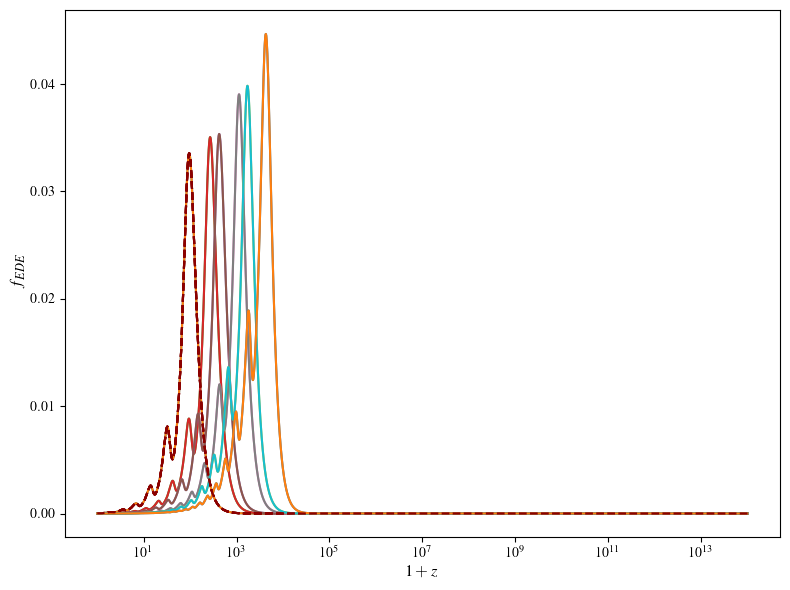

In [38]:
# Prepare the data
z = bg_m['z']
z1 = bg1['z']
# z_eq = derived['z_eq']
# z_rec = derived['z_rec']
#w_fld_EDE1 = bg1['(.)w_fld']
#w_fld_EDEm = bg_m['(.)w_fld']
rho_EDE_m0 = bg1['(.)rho_scf']
fig, ax = plt.subplots()
rho_tot_EDE_m = bg_m['(.)rho_tot']
for i in range(0,6):
    f_EDE = bg_m['(.)rho_mscf['+str(i)+']']/rho_tot_EDE_m
    ax.plot(1+z, f_EDE, label=r'$rho_{EDE}$', )
    ax.plot(1+z, f_EDE, label=r'$f_{EDE}$', )
    ax.plot(1+z, f_1, label=r'$f_{mEDE}$', color='darkred', linestyle='dashed')
rho_EDE_m1 = bg_m['(.)rho_mscf[0]']
f_1 = rho_EDE_m1 / rho_tot_EDE_m  # This will go on the right-hand y-axis

#rho_EDEm = bg_m['(.)rho_fld']
#rho_tot_EDEm = bg_m['(.)rho_tot']
#f_m = rho_EDEm / rho_tot_EDEm  # This will go on the right-hand y-axis
# ax.plot(1+z1, rho_EDE_m0, label=r'$rho_{EDE}$', color='darkred')
# ax.plot(1+z, rho_EDE_m1, label=r'$rho_{mEDE}$', color='darkred', linestyle='dashed')
#ax.plot(z, f_m, label=r'$f_{mEDE}$', color='darkblue')
ax.set_xlabel(r'$1+z$',fontsize='large')
ax.set_ylabel(r'$f_{EDE}$',fontsize='large')
#ax.set_ylim(0, .1)  # Set based on physical expectations
# ax.set_xlim(0, 10000)  # Set based on physical expectations
#ax.tick_params(colors='darkred')

# lines, labels = ax.get_legend_handles_labels()
# ax.legend(lines, labels, loc='upper right', bbox_to_anchor=(1, 1))
ax.set_xscale('log')
# ax.set_yscale('log')

plt.tight_layout()
plt.show()

(2, 3000)

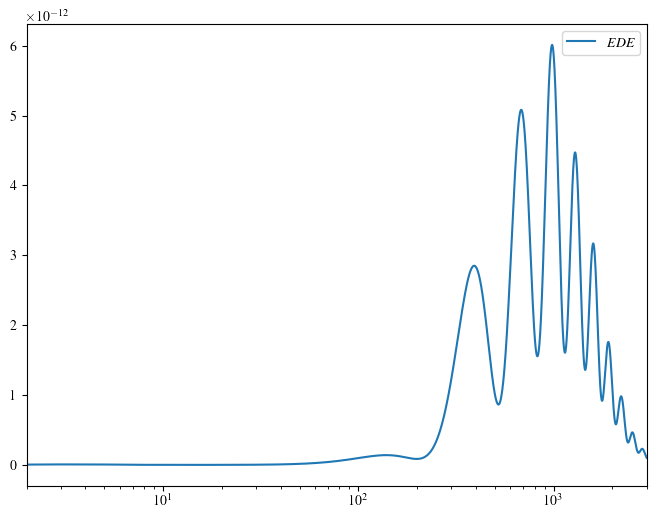

In [23]:
cl_tot_1 = EDE1.raw_cl(3000)
cl_tot_m = EDEm.raw_cl(3000)
ell_1 = cl_tot_1['ell']
ell_m = cl_tot_m['ell']


#plt.plot(ell_1, cl_tot_1['ee']*ell_1*(ell_1+1.)/2./np.pi, label=r'$EDE$')
plt.plot(ell_1, cl_tot_m['ee']*ell_m*(ell_m+1.)/2./np.pi, label=r'$EDE$')

#plt.plot(ell_m, (cl_tot_1['tt']-cl_tot_m['tt'])/cl_tot_1['tt']*100, label=r'$mEDE$')
#plt.plot(ell_m, (cl_tot_1['ee']-cl_tot_m['ee'])/cl_tot_1['ee']*100, label=r'$mEDE$')
plt.xscale('log')
plt.legend()
plt.xlim([2,3000])